In [1]:
#首先将相应的包导入程序
import tensorflow as tf
from tensorflow.keras import layers,models

In [2]:
#获取数据集
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

In [3]:
#打印一下X_train和y_train的形状
print(X_train.shape)
print(y_train.shape)

(60000, 28, 28)
(60000,)


In [4]:
#为了防止后面的数据爆掉，简单做一下归一化
X_train = X_train / 255.0
X_test = X_test / 255.0

In [19]:
#将每一张图片reshape成三维的，便于训练卷积神经网络：
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [22]:
#接下来搭建卷积神经网络，选择早期的LeNet作为例子，由两个卷积层和两个全连接层组成，代码如下：
model = models.Sequential()

# 第一层：卷积层
model.add(layers.Conv2D(6, (5, 5), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))

# 第二层：卷积层
model.add(layers.Conv2D(16, (5, 5), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# 展平层
model.add(layers.Flatten())

# 第三层：全连接层
model.add(layers.Dense(120, activation='relu'))

# 第四层：全连接层
model.add(layers.Dense(84, activation='relu'))

# 输出层
model.add(layers.Dense(10, activation='softmax'))

#看看模型的结构
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 24, 24, 6)         156       
                                                                 


 max_pooling2d_2 (MaxPoolin  (None, 12, 12, 6)         0         
 g2D)                                                            
                                                                 
 conv2d_3 (Conv2D)           (None, 8, 8, 16)          2416      
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 4, 4, 16)          0         
 g2D)                                                            
                                                                 
 flatten_2 (Flatten)         (None, 256)               0         
                                                                 
 dense_5 (Dense)             (None, 120)               30840     
                                                                 
 dense_6 (Dense)             (None, 84)                10164     
                                                                 
 dense_7 (Dense)             (None, 10)                850       
          

In [41]:
#构建好CNN框架之后，我们来编译模型：
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
#为何使用交叉熵作为损失函数？因为这是一个多分类问题，交叉熵能够更好地衡量模型输出的概率分布与真实标签之间的差距。

Epoch 1/10
469/469 [==============================] - 2s 4ms/step - loss: 0.0187 - accuracy: 0.9938
Epoch 2/10
469/469 [==============================] - 2s 4ms/step - loss: 0.0151 - accuracy: 0.9952
Epoch 3/10
469/469 [==============================] - 2s 4ms/step - loss: 0.0130 - accuracy: 0.9956
Epoch 4/10
469/469 [==============================] - 2s 4ms/step - loss: 0.0121 - accuracy: 0.9959
Epoch 5/10
469/469 [==============================] - 2s 4ms/step - loss: 0.0097 - accuracy: 0.9969
Epoch 6/10
469/469 [==============================] - 2s 4ms/step - loss: 0.0089 - accuracy: 0.9971
Epoch 7/10
469/469 [==============================] - 2s 4ms/step - loss: 0.0085 - accuracy: 0.9973
Epoch 8/10
469/469 [==============================] - 2s 4ms/step - loss: 0.0078 - accuracy: 0.9973
Epoch 9/10
469/469 [==============================] - 2s 4ms/step - loss: 0.0076 - accuracy: 0.9973
Epoch 10/10
469/469 [==============================] - 2s 4ms/step - loss: 0.0081 - accuracy: 0.9972

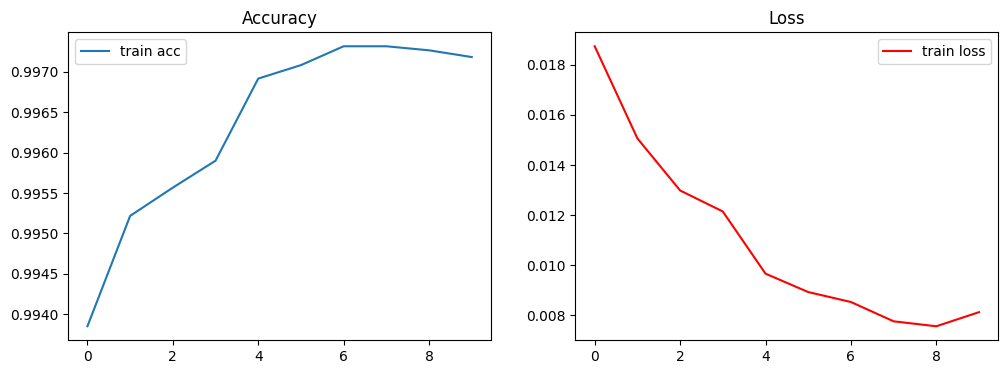

In [44]:
#接下来训练模型：
history = model.fit(X_train, y_train, epochs=10, batch_size=128)

# 画图
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

# 准确率
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train acc')
plt.title('Accuracy')
plt.legend()

# 损失
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train loss', color='red')
plt.title('Loss')
plt.legend()

plt.show()

In [45]:
#评估模型：
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test accuracy: {test_acc}')

313/313 [==============================] - 1s 1ms/step - loss: 0.0447 - accuracy: 0.9887
Test accuracy: 0.9886999726295471


In [46]:
#把测试结果保存下来：
predictions = model.predict(X_test)
predicted_labels = tf.argmax(predictions, axis=1)

313/313 [==============================] - 0s 1ms/step


In [47]:
#然后抽取一部分测试机，这里我们抽取10个：
random_indices = tf.random.uniform((15,), maxval=len(X_test), dtype=tf.int32)

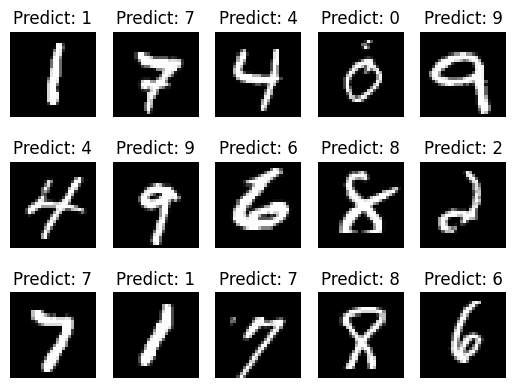

In [48]:
#绘图：
for i, idx in enumerate(random_indices):
    image = X_test[idx].squeeze()
    true_label = y_test[idx]
    predicted_label = predicted_labels[idx]
    plt.subplot(3, 5, i+1)
    plt.imshow(image, cmap='gray')
    plt.title(f'Predict: {predicted_label}')
    plt.axis('off')

plt.show()